In [ ]:
#Name:Susmita Kunwar
#Student_Number:2461844
#Class:L5CG7

#Implementation of Sigmoid Regression from Scratch.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 1. Task To Do:
# • Implement the Logistic Function by completing the code or writing your own function.
# • Make sure you pass the test case.

# Implementation of Sigmoid Function:

def logistic_function(x):
    """
    Computes the logistic (sigmoid) function applied to any value of x.

    Arguments:
    x: scalar or numpy array of any size.

    Returns:
    y: logistic function applied to x.
    """

    y = 1 / (1 + np.exp(-x))
    return y
print(logistic_function(0))

0.5


In [ ]:
# Test Case for logistic function:
def test_logistic_function():
    """
    Test cases for the logistic_function.
    """

    # Test with scalar input
    x_scalar = 0
    expected_output_scalar = round(1 / (1 + np.exp(0)), 3)  # Expected output: 0.5
    assert round(logistic_function(x_scalar), 3) == expected_output_scalar, \
        "Test failed for scalar input"

    # Test with positive scalar input
    x_pos = 2
    expected_output_pos = round(1 / (1 + np.exp(-2)), 3)  # Expected output: ~0.881
    assert round(logistic_function(x_pos), 3) == expected_output_pos, \
        "Test failed for positive scalar input"

    # Test with negative scalar input
    x_neg = -3
    expected_output_neg = round(1 / (1 + np.exp(3)), 3)  # Expected output: ~0.047
    assert round(logistic_function(x_neg), 3) == expected_output_neg, \
        "Test failed for negative scalar input"

    # Test with numpy array input
    x_array = np.array([0, 2, -3])
    expected_output_array = np.array([0.5, 0.881, 0.047])

    # Use np.round to round the array element-wise and compare
    assert np.all(np.round(logistic_function(x_array), 3) == expected_output_array), \
        "Test failed for numpy array input"

    print("All tests passed!")


# Run the test case
test_logistic_function()


All tests passed!


In [ ]:
# 2. Task To Do:
# • Implement the Log - loss Function by completing the code or writing your own function.
# • Make sure you pass the test case.

# Implementation of log-loss function:

def log_loss(y_true, y_pred):
    """
    Computes log loss for true target value y ∈ {0, 1}
    and predicted target value ŷ ∈ (0, 1).

    Arguments:
    y_true (scalar): true target value (0 or 1)
    y_pred (scalar): predicted target probability (0 to 1)

    Returns:
    loss (float): log loss value
    """

    # Ensure y_pred is clipped to avoid log(0)
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)

    # Log loss formula
    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    return loss
print(log_loss(1, 0.9))   # Low loss (good prediction)
print(log_loss(1, 0.1))   # High loss (bad prediction)
print(log_loss(0, 0.8))   # High loss
print(log_loss(0, 0.2))   # Low loss

0.10536051565782628
2.3025850929940455
1.6094379124341005
0.2231435513142097


In [ ]:
#Verifying the Intution:

# Test function:

y_true, y_pred = 0, 0.1
print(f'log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}')

print("--" *30)

y_true, y_pred = 1, 0.9
print(f'log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}')


log loss(0, 0.1) ==> 0.10536051565782628
------------------------------------------------------------
log loss(1, 0.9) ==> 0.10536051565782628


In [ ]:
#Test Case for log - loss function:

def test_log_loss():
    """
    Test cases for the log_loss function.
    """

    # Test case 1: Perfect prediction (y_true = 1, y_pred = 1)
    y_true = 1
    y_pred = 1
    expected_loss = 0.0
    assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol=1e-6), \
        "Test failed for perfect prediction (y_true=1, y_pred=1)"

    # Test case 2: Perfect prediction (y_true = 0, y_pred = 0)
    y_true = 0
    y_pred = 0
    expected_loss = 0.0
    assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol=1e-6), \
        "Test failed for perfect prediction (y_true=0, y_pred=0)"

    # Test case 3: Completely wrong prediction (y_true = 1, y_pred = 0)
    y_true = 1
    y_pred = 0
    loss = log_loss(y_true, y_pred)
    assert loss > 10, "Test failed for highly incorrect prediction (y_true=1, y_pred=0)"

    # Test case 4: Completely wrong prediction (y_true = 0, y_pred = 1)
    y_true = 0
    y_pred = 1
    loss = log_loss(y_true, y_pred)
    assert loss > 10, "Test failed for highly incorrect prediction (y_true=0, y_pred=1)"

    # Test case 5: Partially correct prediction
    y_true = 1
    y_pred = 0.8
    expected_loss = -np.log(0.8)  # ≈ 0.2231
    assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol=1e-6), \
        "Test failed for partially correct prediction (y_true=1, y_pred=0.8)"

    y_true = 0
    y_pred = 0.2
    expected_loss = -np.log(0.8)  # ≈ 0.2231
    assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol=1e-6), \
        "Test failed for partially correct prediction (y_true=0, y_pred=0.2)"

    print("All tests passed!")


# Run the test case
test_log_loss()


All tests passed!


In [ ]:
# 3. Task To Do:
# • Implement the Cost Function by completing the code or writing your own function.
# • Make sure you pass the test case.

# Implemenetation of Cost Function:

def cost_function(y_true, y_pred):
    """
    Computes log loss (binary cross-entropy) cost for arrays of true and predicted values.

    Args:
    y_true (array_like, shape (n,)): array of true values (0 or 1)
    y_pred (array_like, shape (n,)): array of predicted probabilities (between 0 and 1)

    Returns:
    cost (float): nonnegative cost corresponding to y_true and y_pred
    """
    assert len(y_true) == len(y_pred), \
        "Length of true values and length of predicted values do not match"

    n = len(y_true)

    # Clip y_pred to avoid log(0)
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)

    # Vectorized log loss for all examples
    loss_vec = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    # Average cost
    cost = np.mean(loss_vec)

    return cost


def test_cost_function():
    """
    Test case for cost_function
    """
    y_true = np.array([1, 0, 1])
    y_pred = np.array([0.9, 0.1, 0.8])

    # Manually compute expected cost
    expected_cost = (
        -(1 * np.log(0.9) + (1 - 1) * np.log(1 - 0.9)) +
        -(0 * np.log(0.1) + (1 - 0) * np.log(1 - 0.1)) +
        -(1 * np.log(0.8) + (1 - 1) * np.log(1 - 0.8))
    ) / 3

    # Call the cost_function
    result = cost_function(y_true, y_pred)

    # Check if result matches expected cost
    assert np.isclose(result, expected_cost, atol=1e-6), \
        f"Test failed: {result} != {expected_cost}"

    print("Test passed for simple case!")


# Run the test
test_cost_function()


Test passed for simple case!


In [ ]:
# 4. Task To Do:
# • Implement the vectorized cost function costfunction logreg Function by completing the
# code or writing your own function.
# • Make sure you pass the test case.

# Implementation of Cost Function for Logistic/Sigmoid Regression:
# Function to compute cost function in terms of model parameters - using vectorization

def costfunction_logreg(X, y, w, b):
    """
    Computes the cost function (binary cross-entropy) for logistic regression.

    Args:
    X (ndarray, shape (m, n)): data with m observations and n features
    y (array_like, shape (m,)): true target values (0 or 1)
    w (array_like, shape (n,)): weight parameters
    b (float): bias parameter

    Returns:
    cost (float): nonnegative cost
    """
    n, d = X.shape
    assert len(y) == n, "Number of feature observations and number of target observations do not match."
    assert len(w) == d, "Number of features and number of weight parameters do not match."

    # Compute linear combination z = Xw + b
    z = np.dot(X, w) + b

    # Compute predictions using sigmoid
    y_pred = logistic_function(z)

    # Compute the cost using the previously defined cost_function
    cost = cost_function(y, y_pred)

    return cost

# Testing the Function:
X, y, w, b = np.array([[10, 20], [-10, 10]]), np.array([1, 0]), np.array([0.5, 1.5]), 1
print(f"cost for logistic regression(X = {X}, y = {y}, w = {w}, b = {b}) = {costfunction_logreg(X, y, w, b)}")

cost for logistic regression(X = [[ 10  20]
 [-10  10]], y = [1 0], w = [0.5 1.5], b = 1) = 5.500008350834906


In [ ]:
# Implementation with Code:
# 5. Task To Do:
# • Implement the compute gradient Function by completing the code or writing your own
# function.
# • Make sure you pass the test case.

# Computing Gradients for Sigmoid Regression:

def compute_gradient(X, y, w, b):
    """
    Computes gradients of the cost function with respect to model parameters.

    Args:
    X (ndarray, shape (n,d)): Input data, n observations with d features
    y (array_like, shape (n,)): True labels (0 or 1)
    w (array_like, shape (d,)): Weight parameters
    b (float): Bias parameter

    Returns:
    grad_w (array_like, shape (d,)): Gradients w.r.t weight parameters
    grad_b (float): Gradient w.r.t bias parameter
    """
    n, d = X.shape
    assert len(y) == n, f"Expected y to have {n} elements, but got {len(y)}"
    assert len(w) == d, f"Expected w to have {d} elements, but got {len(w)}"

    # Compute linear combination z = Xw + b
    z = np.dot(X, w) + b

    # Compute predictions using sigmoid
    y_pred = logistic_function(z)

    # Compute gradients
    error = y_pred - y  # shape (n,)
    grad_w = np.dot(X.T, error) / n  # shape (d,)
    grad_b = np.sum(error) / n       # scalar

    return grad_w, grad_b

# A simple assertion test for compute gradient function:

# Simple test case
X = np.array([[10, 20], [-10, 10]]) # shape (2, 2)
y = np.array([1, 0]) # shape (2,)
w = np.array([0.5, 1.5]) # shape (2,)
b = 1 # scalar
# Assertion tests
try:
    grad_w, grad_b = compute_gradient(X, y, w, b)
    print("Gradients computed successfully.")
    print(f"grad_w: {grad_w}")
    print(f"grad_b: {grad_b}")
except AssertionError as e:
    print(f"Assertion error: {e}")

Gradients computed successfully.
grad_w: [-4.99991649  4.99991649]
grad_b: 0.4999916492890759


In [ ]:
# 6. Task To Do:
# • Implement the gradient descent Function by completing the code or writing your own
# function.
# • Make sure you pass the test case.

# Gradient Descent for Sigmoid Regression:

def gradient_descent(X, y, w, b, alpha, n_iter, show_cost=False, show_params=True):
    n, d = X.shape
    assert len(y) == n, "Number of observations in X and y do not match"
    assert len(w) == d, "Number of features in X and w do not match"

    cost_history = []
    params_history = []

    for i in range(n_iter):
        # Compute gradients
        grad_w, grad_b = compute_gradient(X, y, w, b)

        # Update weights and bias
        w -= alpha * grad_w
        b -= alpha * grad_b

        # Compute cost
        z = np.dot(X, w) + b
        y_pred = logistic_function(z)
        cost = cost_function(y, y_pred)

        # Store cost and parameters
        cost_history.append(cost)
        params_history.append((w.copy(), b))

        # Optionally print cost and parameters
        if (show_cost or show_params) and (i % 100 == 0 or i == n_iter - 1):
            if show_cost:
                print(f"Iteration {i}: Cost = {cost:.6f}")
            if show_params:
                print(f"Iteration {i}: w = {w}, b = {b:.6f}")

    return w, b, cost_history, params_history

# Test the gradient_descent function with sample data
X = np.array([[0.1, 0.2], [-0.1, 0.1]])  # Shape (2, 2)
y = np.array([1, 0])                     # Shape (2,)
w = np.zeros(X.shape[1])                 # Shape (2,)
b = 0.0                                  # Scalar
alpha = 0.1                              # Learning rate
n_iter = 100000                          # Number of iterations

# Perform gradient descent
w_out, b_out, cost_history, params_history = gradient_descent(
    X, y, w, b, alpha, n_iter, show_cost=True, show_params=False
)

# Print final parameters and cost
print("\nFinal parameters:")
print(f"w: {w_out}, b: {b_out}")
print(f"Final cost: {cost_history[-1]:.6f}")


Iteration 0: Cost = 0.692835
Iteration 100: Cost = 0.662662
Iteration 200: Cost = 0.634332
Iteration 300: Cost = 0.607704
Iteration 400: Cost = 0.582671
Iteration 500: Cost = 0.559128
Iteration 600: Cost = 0.536977
Iteration 700: Cost = 0.516126
Iteration 800: Cost = 0.496487
Iteration 900: Cost = 0.477978
Iteration 1000: Cost = 0.460524
Iteration 1100: Cost = 0.444052
Iteration 1200: Cost = 0.428497
Iteration 1300: Cost = 0.413797
Iteration 1400: Cost = 0.399895
Iteration 1500: Cost = 0.386736
Iteration 1600: Cost = 0.374272
Iteration 1700: Cost = 0.362457
Iteration 1800: Cost = 0.351248
Iteration 1900: Cost = 0.340607
Iteration 2000: Cost = 0.330495
Iteration 2100: Cost = 0.320880
Iteration 2200: Cost = 0.311730
Iteration 2300: Cost = 0.303016
Iteration 2400: Cost = 0.294710
Iteration 2500: Cost = 0.286789
Iteration 2600: Cost = 0.279228
Iteration 2700: Cost = 0.272007
Iteration 2800: Cost = 0.265104
Iteration 2900: Cost = 0.258502
Iteration 3000: Cost = 0.252182
Iteration 3100: Cost

In [ ]:
#A simple assertion test for gradient descent Function:

# Simple assertion test for gradient_descent

def test_gradient_descent():
    """
    Simple assertion test for gradient_descent function.
    """
    X = np.array([[0.1, 0.2], [-0.1, 0.1]])  # Shape (2, 2)
    y = np.array([1, 0])                     # Shape (2,)
    w = np.zeros(X.shape[1])                 # Shape (2,)
    b = 0.0                                  # Scalar
    alpha = 0.1                              # Learning rate
    n_iter = 100                             # Number of iterations

    # Run gradient descent
    w_out, b_out, cost_history, _ = gradient_descent(
        X, y, w, b, alpha, n_iter, show_cost=False, show_params=False
    )

    # Assertions
    assert len(cost_history) == n_iter, "Cost history length does not match the number of iterations"
    assert w_out.shape == w.shape, "Shape of output weights does not match the initial weights"
    assert isinstance(b_out, float), "Bias output is not a float"
    assert cost_history[-1] < cost_history[0], "Cost did not decrease over iterations"

    print("All tests passed!")

# Run the test
test_gradient_descent()


All tests passed!


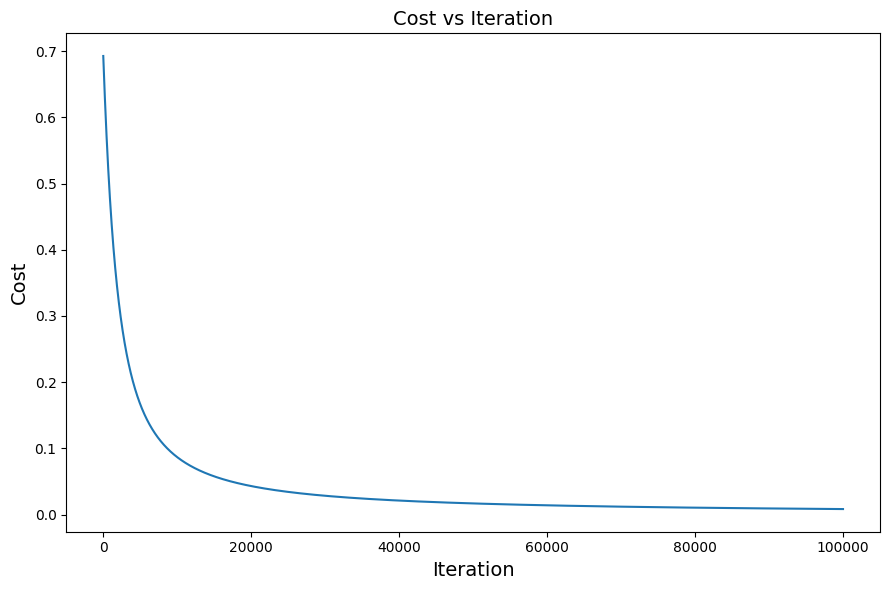

In [ ]:
#Code for Plotting Cost Vs. Iteration during Gradient Descent:

# Plotting cost over iteration
plt.figure(figsize = (9, 6))
plt.plot(cost_history)
plt.xlabel("Iteration", fontsize = 14)
plt.ylabel("Cost", fontsize = 14)
plt.title("Cost vs Iteration", fontsize = 14)
plt.tight_layout()
plt.show()

In [ ]:
# 7. Task To Do:
# • Implement the prediction Function by completing the code or writing your own function.
# • Make sure you pass the test case.

# Decision/Prediction Function:

def prediction(X, w, b, threshold=0.5):
    """
    Predicts binary outcomes for given input features based on logistic regression parameters.

    Arguments:
    X (ndarray, shape (n,d)): Test features (n samples, d features)
    w (ndarray, shape (d,)): Learned weights
    b (float): Learned bias
    threshold (float, optional): Classification threshold. Default 0.5.

    Returns:
    y_pred (ndarray, shape (n,)): Predicted class labels (0 or 1)
    """
    # Compute predicted probabilities
    y_test_prob = logistic_function(np.dot(X, w) + b)

    # Classify based on threshold
    y_pred = (y_test_prob >= threshold).astype(int)

    return y_pred



#A simple assertion test for Prediction Function:
def test_prediction():
    X_test = np.array([[0.5, 1.0], [1.5, -0.5], [-0.5, -1.0]])  # Shape (3, 2)
    w_test = np.array([1.0, -1.0])                               # Shape (2,)
    b_test = 0.0                                                 # Scalar bias
    threshold = 0.5                                               # Default threshold

    # Expected output (computed manually)
    expected_output = np.array([0, 1, 1])

    # Call the prediction function
    y_pred = prediction(X_test, w_test, b_test, threshold)

    # Assert equality
    assert np.array_equal(y_pred, expected_output), f"Expected {expected_output}, but got {y_pred}"
    print("Test passed!")

# Run the test
test_prediction()


Test passed!


In [ ]:
# 8. Task To Do:
# • Implement evaluate classification Function by completing the code or writing your own
# function.
# • Make sure you pass the test case.

# Evaluation of the Classifier:

import numpy as np

def evaluate_classification(y_true, y_pred):
    """
    Computes the confusion matrix, precision, recall, and F1-score for binary classification.

    Arguments:
    y_true (ndarray, shape (n,)): Ground truth binary labels (0 or 1)
    y_pred (ndarray, shape (n,)): Predicted binary labels (0 or 1)

    Returns:
    metrics (dict): Dictionary containing confusion matrix, precision, recall, and F1-score
    """
    # Confusion matrix components
    TP = np.sum((y_true == 1) & (y_pred == 1))  # True Positives
    TN = np.sum((y_true == 0) & (y_pred == 0))  # True Negatives
    FP = np.sum((y_true == 0) & (y_pred == 1))  # False Positives
    FN = np.sum((y_true == 1) & (y_pred == 0))  # False Negatives

    # Confusion matrix
    confusion_matrix = np.array([[TN, FP],
                                 [FN, TP]])

    # Precision, recall, F1-score
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    # Metrics dictionary
    metrics = {
        "confusion_matrix": confusion_matrix,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }

    return metrics


def test_evaluate_classification():
    y_true = np.array([1, 0, 1, 0, 1, 0])
    y_pred = np.array([1, 0, 0, 0, 1, 1])

    metrics = evaluate_classification(y_true, y_pred)

    expected_confusion_matrix = np.array([[2, 1],
                                          [1, 2]])
    expected_precision = 2 / (2 + 1)  # 0.6667
    expected_recall = 2 / (2 + 1)     # 0.6667
    expected_f1 = 2 * expected_precision * expected_recall / (expected_precision + expected_recall)  # 0.6667

    assert np.array_equal(metrics["confusion_matrix"], expected_confusion_matrix), "Confusion matrix mismatch"
    assert np.isclose(metrics["precision"], expected_precision), "Precision mismatch"
    assert np.isclose(metrics["recall"], expected_recall), "Recall mismatch"
    assert np.isclose(metrics["f1_score"], expected_f1), "F1-score mismatch"

    print("All tests passed!")

# Run the test
test_evaluate_classification()


All tests passed!


In [ ]:
#Sigmoid Regression for the dataset


# Load dataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction', 'Age', 'Outcome']
data_pima_diabetes = pd.read_csv(url, names=columns)


In [ ]:
# Data cleaning
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data_pima_diabetes[columns_to_clean] = data_pima_diabetes[columns_to_clean].replace(0, np.nan)
data_pima_diabetes.fillna(data_pima_diabetes.median(), inplace=True)
data_pima_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [ ]:
data_pima_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
#Train Test Split and Standard Scaling of the Data

# Train-test split
X = data_pima_diabetes.drop(columns=['Outcome']).values
y = data_pima_diabetes['Outcome'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)





Training Logistic Regression Model:
Iteration 0: Cost = 0.676575
Iteration 100: Cost = 0.465441
Iteration 200: Cost = 0.455913
Iteration 300: Cost = 0.453874
Iteration 400: Cost = 0.453316
Iteration 500: Cost = 0.453148
Iteration 600: Cost = 0.453096
Iteration 700: Cost = 0.453079
Iteration 800: Cost = 0.453074
Iteration 900: Cost = 0.453072
Iteration 999: Cost = 0.453071


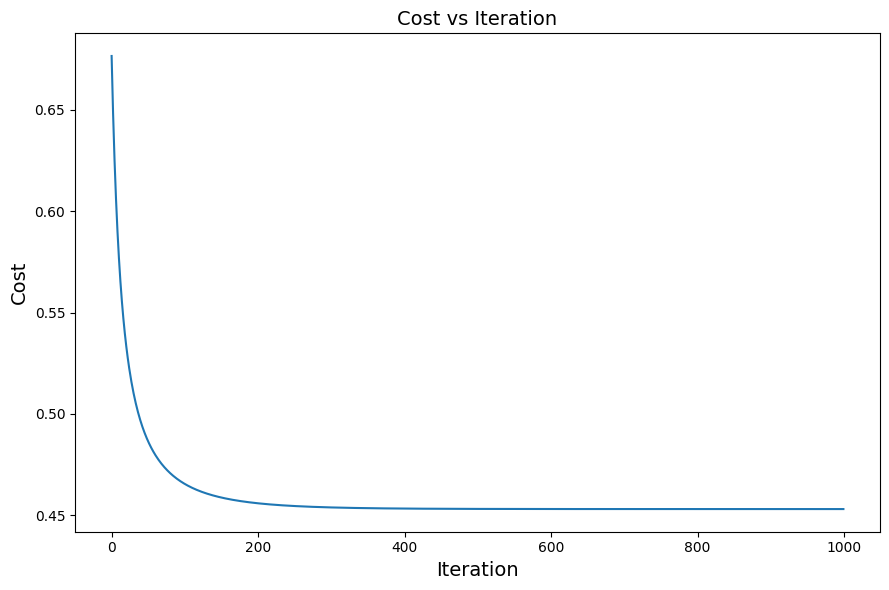

In [ ]:
#Training the model

# Initialize parameters
w = np.zeros(X_train_scaled.shape[1])
b = 0.0
alpha = 0.1
n_iter = 1000

# Train model
print("\nTraining Logistic Regression Model:")
w, b, cost_history,params_history = gradient_descent(X_train_scaled, y_train, w, b, alpha, n_iter,
show_cost=True, show_params=False)
# Plot cost history
plt.figure(figsize=(9, 6))
plt.plot(cost_history)
plt.xlabel("Iteration", fontsize=14)
plt.ylabel("Cost", fontsize=14)
plt.title("Cost vs Iteration", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#Evaluating Train and Test Performance on Cost Value
# Test model
y_train_pred = prediction(X_train_scaled, w, b)
y_test_pred = prediction(X_test_scaled, w, b)
# Evaluate train and test performance
train_cost = costfunction_logreg(X_train_scaled, y_train, w, b)
test_cost = costfunction_logreg(X_test_scaled, y_test, w, b)
print(f"\nTrain Loss (Cost): {train_cost:.4f}")
print(f"Test Loss (Cost): {test_cost:.4f}")


Train Loss (Cost): 0.4531
Test Loss (Cost): 0.5146



Test Accuracy: 70.78%

Confusion Matrix:
[[82 18]
 [27 27]]
Precision: 0.60
Recall: 0.50
F1-Score: 0.55


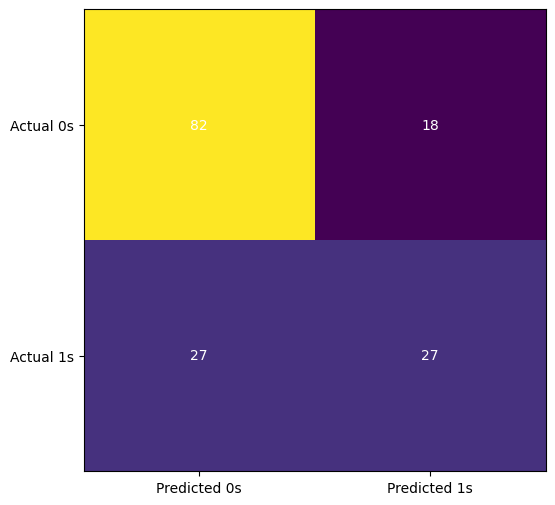

In [ ]:
# Accuracy on test data
test_accuracy = np.mean(y_test_pred == y_test) * 100
print(f"\nTest Accuracy: {test_accuracy:.2f}%")

# Evaluation
metrics = evaluate_classification(y_test, y_test_pred)
print(f"\nConfusion Matrix:\n{metrics['confusion_matrix']}")
print(f"Precision: {metrics['precision']:.2f}")
print(f"Recall: {metrics['recall']:.2f}")
print(f"F1-Score: {metrics['f1_score']:.2f}")

# Optional - Visualizing the Confusion matrix
# Visualizing Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(metrics['confusion_matrix'])
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, metrics['confusion_matrix'][i, j], ha='center', va='center', color='white')
plt.show()